In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
n_r_a = pd.read_csv('C:\\Users\Jide Falowo\Desktop\Dataset J\\nigeria_road_accidents.csv')
n_r_a.head(100)

,STATE ID,STATE,FATAL,SERIOUS,MINOR,TOTAL CASES,NUMBER INJURED,NUMBER KILLED,TOTAL CASUALTY,PEOPLE INVOLVED,PERIOD
0,1,Abia,10,19,1,30,146,31,177,279,Q4 2020
1,2,Adamawa,14,63,0,77,234,36,270,443,Q4 2020
2,3,Akwa Ibom,6,13,3,22,28,7,35,89,Q4 2020
3,4,Anambra,14,41,17,72,152,20,172,526,Q4 2020
4,5,Bauchi,45,108,1,154,685,90,775,1182,Q4 2020
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Kebbi,4,47,2,53,130,4,134,220,Q2 2021
96,97,Kogi,21,57,19,97,246,25,271,705,Q2 2021
97,98,Kwara,32,63,13,108,368,80,448,750,Q2 2021
98,99,Lagos,28,75,42,145,266,47,313,717,Q2 2021


In [5]:
n_r_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   STATE ID         222 non-null    int64 
 1   STATE            222 non-null    object
 2   FATAL            222 non-null    int64 
 3   SERIOUS          222 non-null    int64 
 4   MINOR            222 non-null    int64 
 5   TOTAL CASES      222 non-null    int64 
 6   NUMBER INJURED   222 non-null    int64 
 7   NUMBER KILLED    222 non-null    int64 
 8   TOTAL CASUALTY   222 non-null    int64 
 9   PEOPLE INVOLVED  222 non-null    int64 
 10  PERIOD           222 non-null    object
dtypes: int64(9), object(2)
memory usage: 19.2+ KB


In [6]:
n_r_a.describe()

,STATE ID,FATAL,SERIOUS,MINOR,TOTAL CASES,NUMBER INJURED,NUMBER KILLED,TOTAL CASUALTY,PEOPLE INVOLVED
count,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000
mean,111.500000,22.405405,56.040541,10.225225,88.671171,261.572072,44.400901,305.972973,582.216216
std,64.230055,18.902646,46.875624,16.200768,74.078013,206.973891,40.807423,243.343043,483.002729
min,1.000000,0.000000,1.000000,0.000000,1.000000,3.000000,0.000000,3.000000,3.000000
25%,56.250000,9.000000,20.000000,1.000000,32.000000,119.000000,17.000000,137.250000,229.000000
50%,111.500000,17.000000,44.000000,4.000000,67.000000,212.000000,32.000000,240.500000,419.500000
75%,166.750000,31.000000,75.750000,11.000000,112.250000,346.250000,59.000000,405.750000,782.000000
max,222.000000,104.000000,207.000000,90.000000,337.000000,1149.000000,224.000000,1345.000000,2234.000000


# ACCIDENT SEVERITY DISTRIBUTION

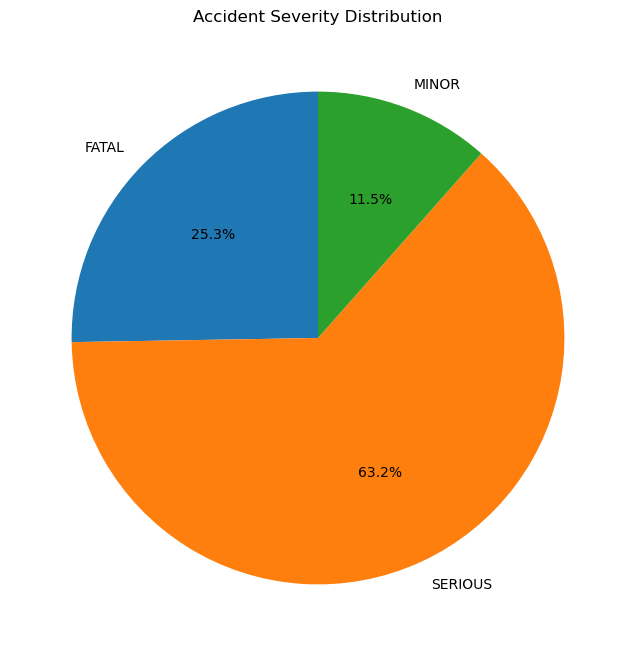

In [7]:
severity = n_r_a[['FATAL', 'SERIOUS', 'MINOR']].sum()

plt.figure(figsize=(8,8))
plt.pie(severity,
    labels=severity.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title("Accident Severity Distribution")
plt.show()

# TOP 10 STATES BY TOTAL CASES

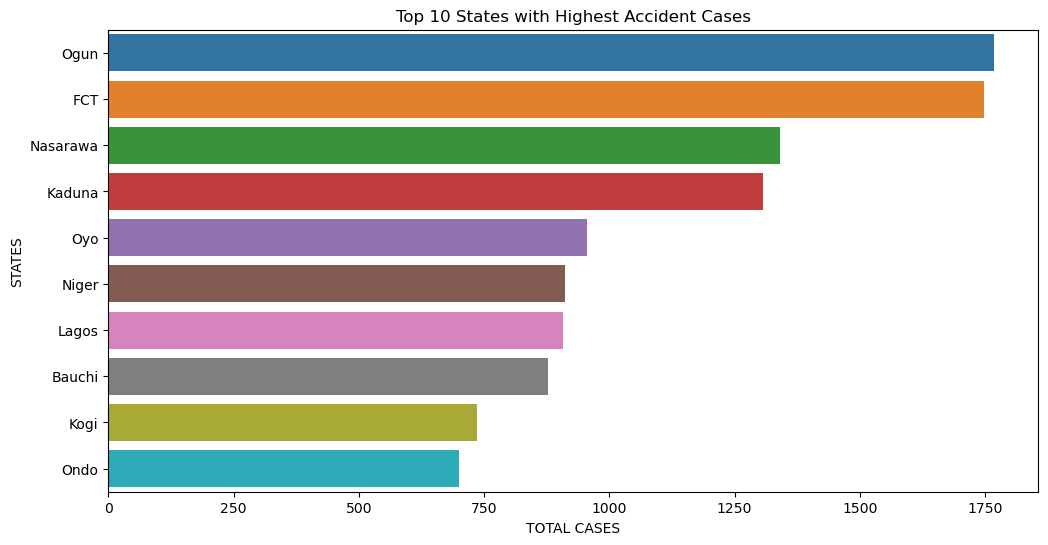

In [16]:
top_cases = (n_r_a.groupby('STATE')['TOTAL CASES']
    .sum()
    .sort_values(ascending=False)
    .head(10))

plt.figure(figsize=(12,6))

sns.barplot(x=top_cases.values,y=top_cases.index)

plt.title("Top 10 States with Highest Accident Cases")
plt.xlabel("TOTAL CASES")
plt.ylabel("STATES")
plt.show()

# TOP 10 STATES BY DEATHS

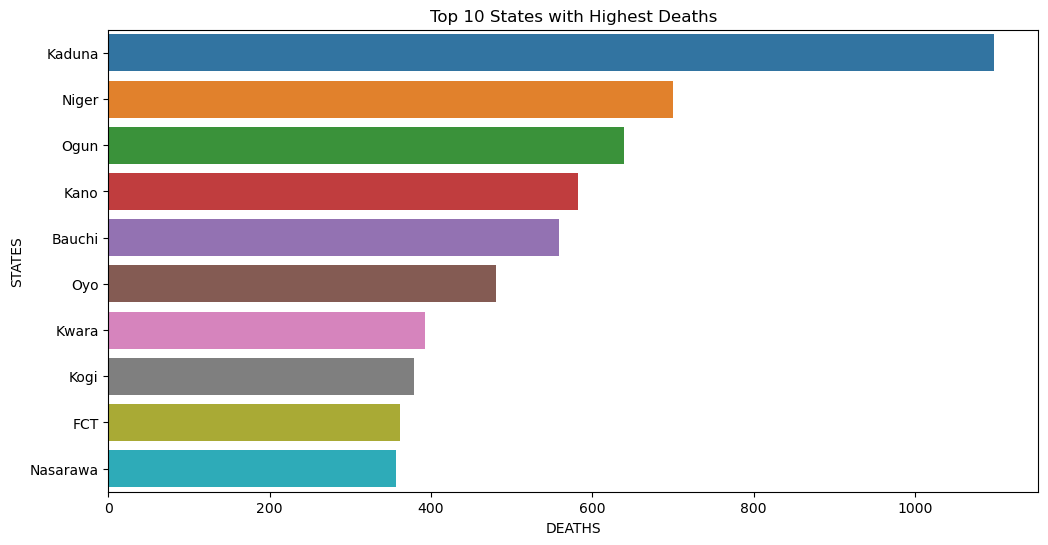

In [18]:
top_deaths = (n_r_a.groupby('STATE')['NUMBER KILLED']
    .sum()
    .sort_values(ascending=False)
    .head(10))

plt.figure(figsize=(12,6))

sns.barplot(x=top_deaths.values,
    y=top_deaths.index)

plt.title("Top 10 States with Highest Deaths")
plt.xlabel("DEATHS")
plt.ylabel("STATES")
plt.show()


# INJURIES VS DEATHS

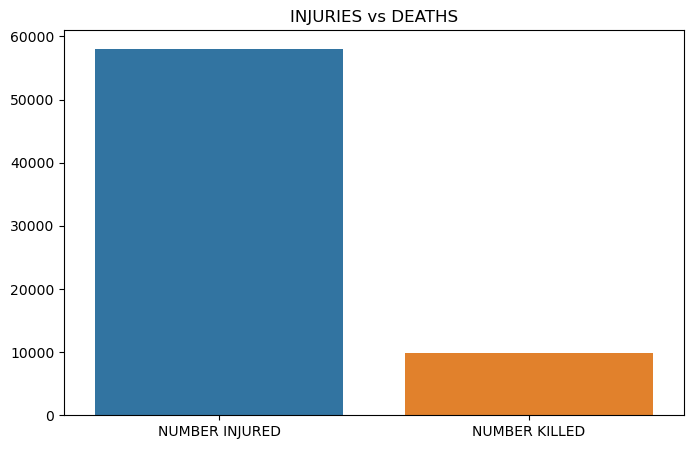

In [19]:
injury_death = n_r_a[['NUMBER INJURED', 'NUMBER KILLED']].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=injury_death.index,y=injury_death.values)

plt.title("INJURIES vs DEATHS")
plt.show()

# FATALITY RATE BY STATE

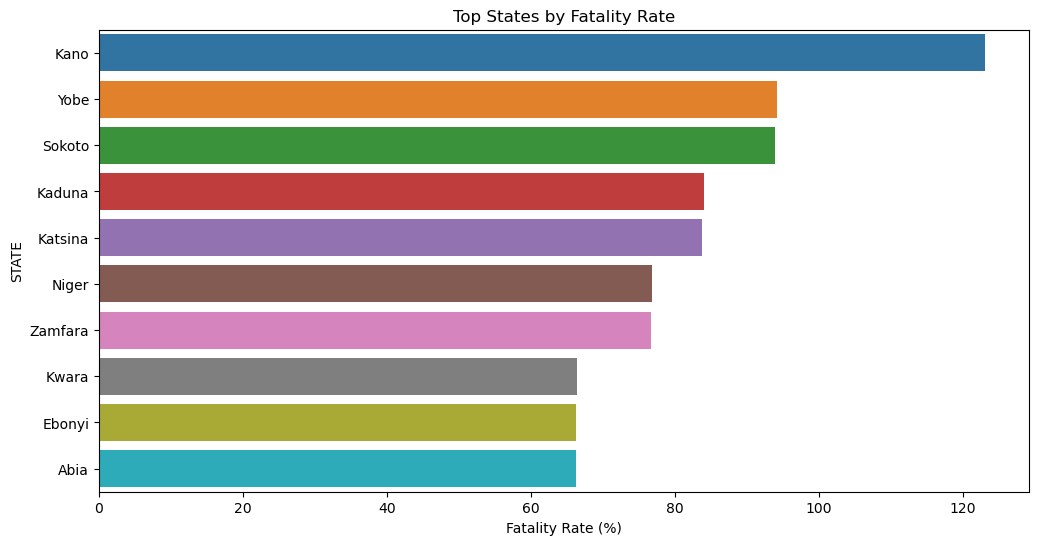

In [21]:
state_summary = n_r_a.groupby('STATE').agg({'NUMBER KILLED':'sum','TOTAL CASES':'sum'})

state_summary['Fatality Rate'] = (state_summary['NUMBER KILLED']
    /
    state_summary['TOTAL CASES']) * 100

top_fatality = (state_summary.sort_values('Fatality Rate',ascending=False).head(10))

plt.figure(figsize=(12,6))

sns.barplot(x=top_fatality['Fatality Rate'],y=top_fatality.index)

plt.title("Top States by Fatality Rate")
plt.xlabel("Fatality Rate (%)")
plt.show()


# CASUALTY TREND OVER TIME

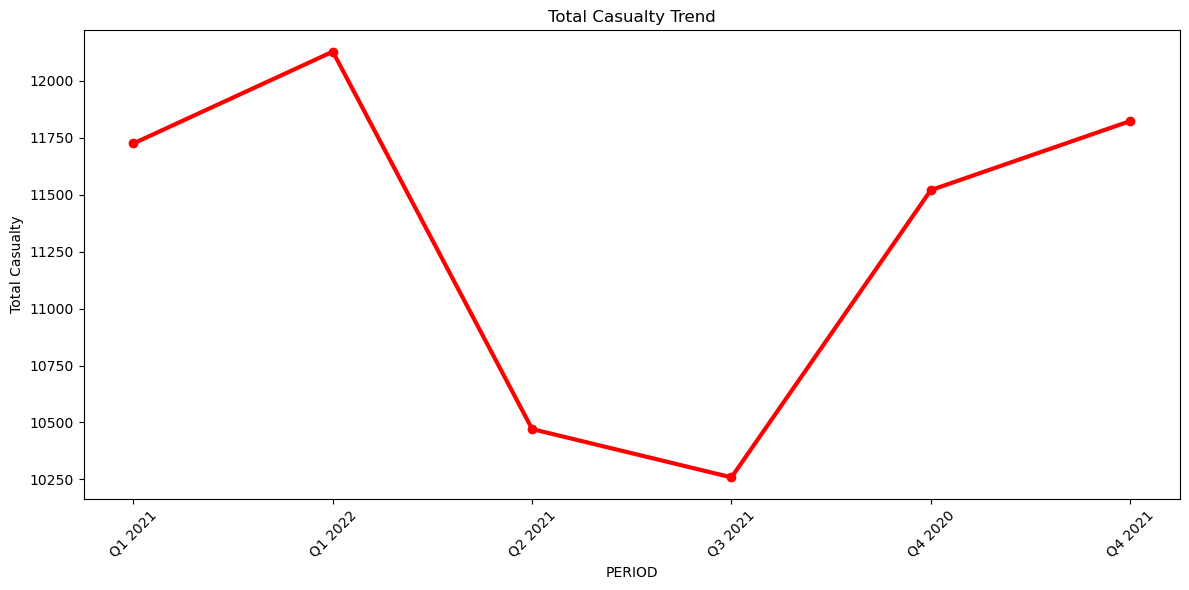

In [23]:
period_trend = (n_r_a.groupby('PERIOD')['TOTAL CASUALTY'].sum())

plt.figure(figsize=(12,6))

plt.plot(period_trend.index,period_trend.values,marker='o',linewidth=3, color = "red")

plt.title("Total Casualty Trend")
plt.xlabel("PERIOD")
plt.ylabel("Total Casualty")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# TOTAL CASES TREND

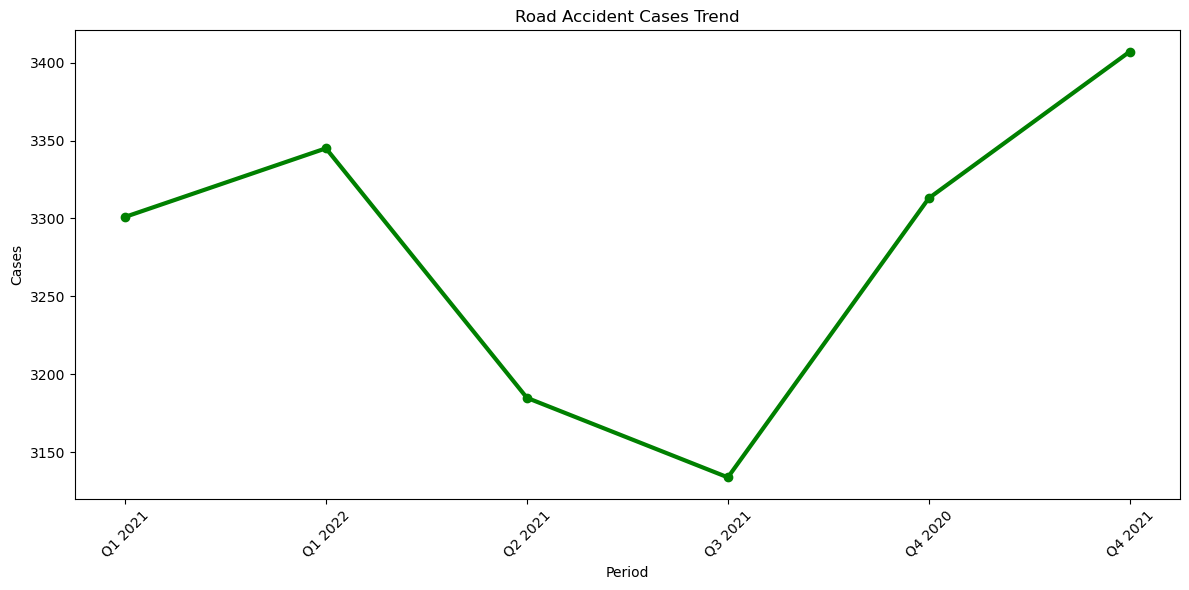

In [26]:
cases_trend = (n_r_a.groupby('PERIOD')['TOTAL CASES'].sum())

plt.figure(figsize=(12,6))

plt.plot(cases_trend.index,cases_trend.values,marker='o',linewidth=3, color = 'Green')

plt.title("Road Accident Cases Trend")
plt.xlabel("Period")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# PEOPLE INVOLVED VS CASUALTY

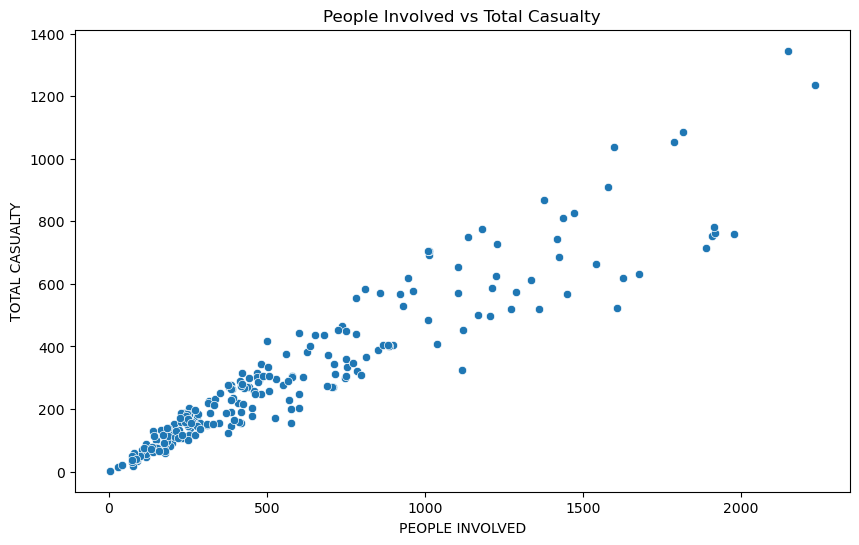

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=n_r_a,x='PEOPLE INVOLVED',y='TOTAL CASUALTY')

plt.title("People Involved vs Total Casualty")

plt.show()


# ACCIDENT SEVERITY BY STATE

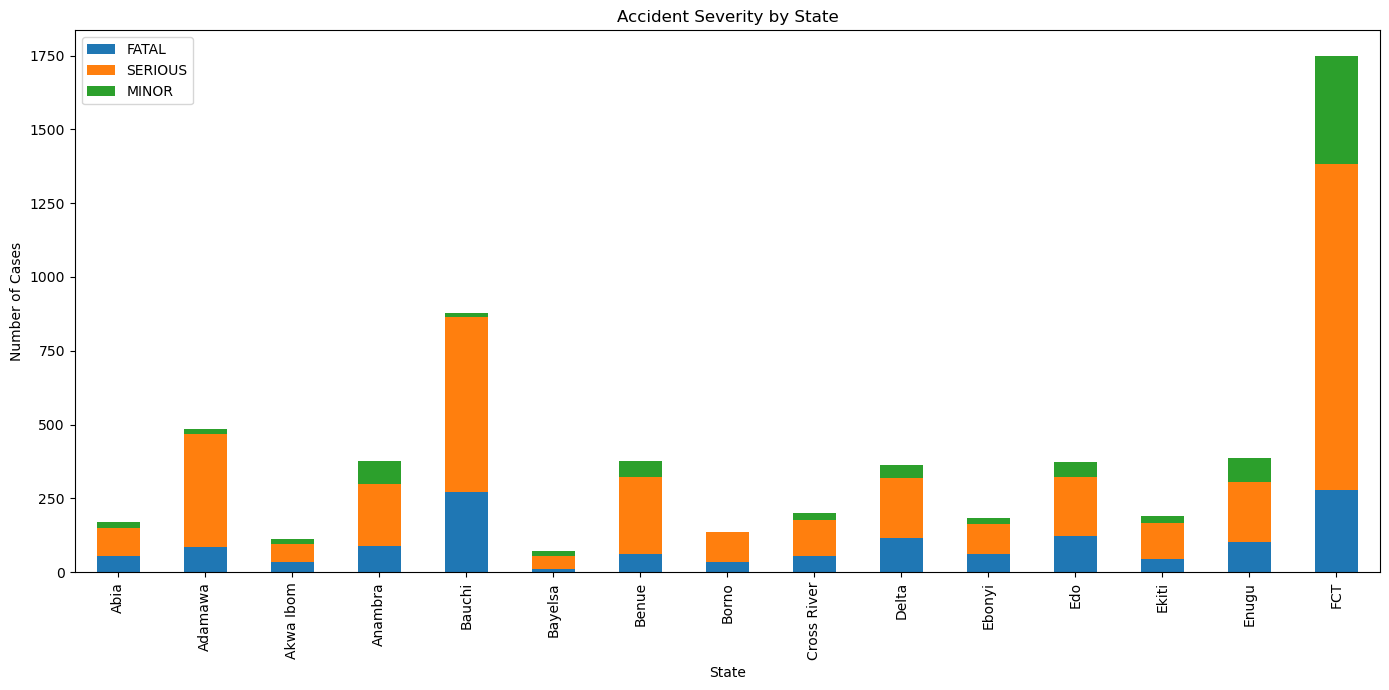

In [35]:
severity_state = (n_r_a.groupby('STATE')[['FATAL', 'SERIOUS', 'MINOR']].sum())

severity_state.head(15).plot(kind='bar',stacked=True,figsize=(14,7))

plt.title("Accident Severity by State")
plt.xlabel("State")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()


# RISK SCORE ANALYSIS

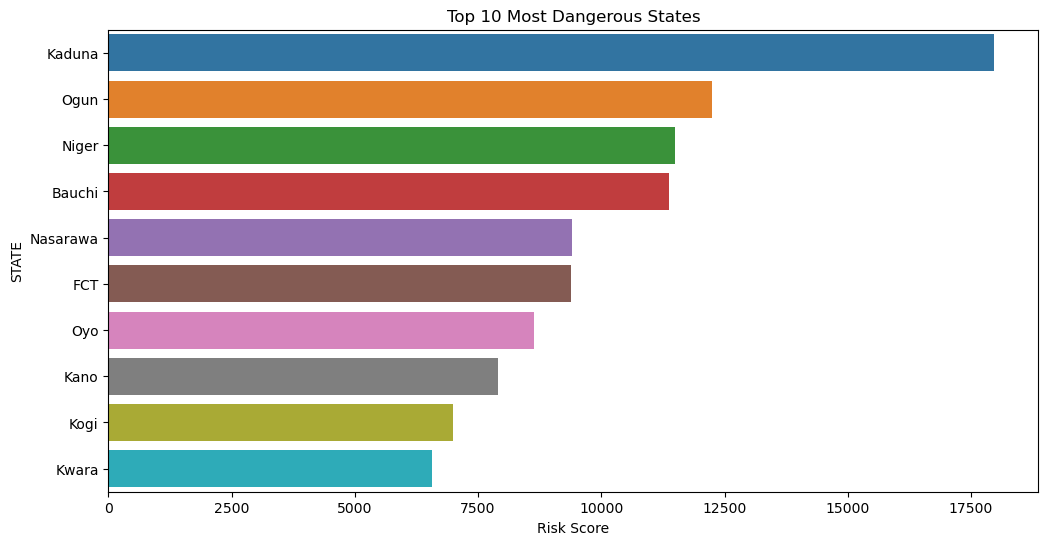

In [37]:
n_r_a['Risk Score'] = (n_r_a['NUMBER KILLED'] * 5+ n_r_a['NUMBER INJURED'] * 2+ n_r_a['FATAL'] * 4)

risk_score = (n_r_a.groupby('STATE')['Risk Score'].sum().sort_values(ascending=False))

plt.figure(figsize=(12,6))

sns.barplot(x=risk_score.head(10).values,y=risk_score.head(10).index)

plt.title("Top 10 Most Dangerous States")

plt.xlabel("Risk Score")
plt.show()


# DASHBOARD STYLE FIGURE

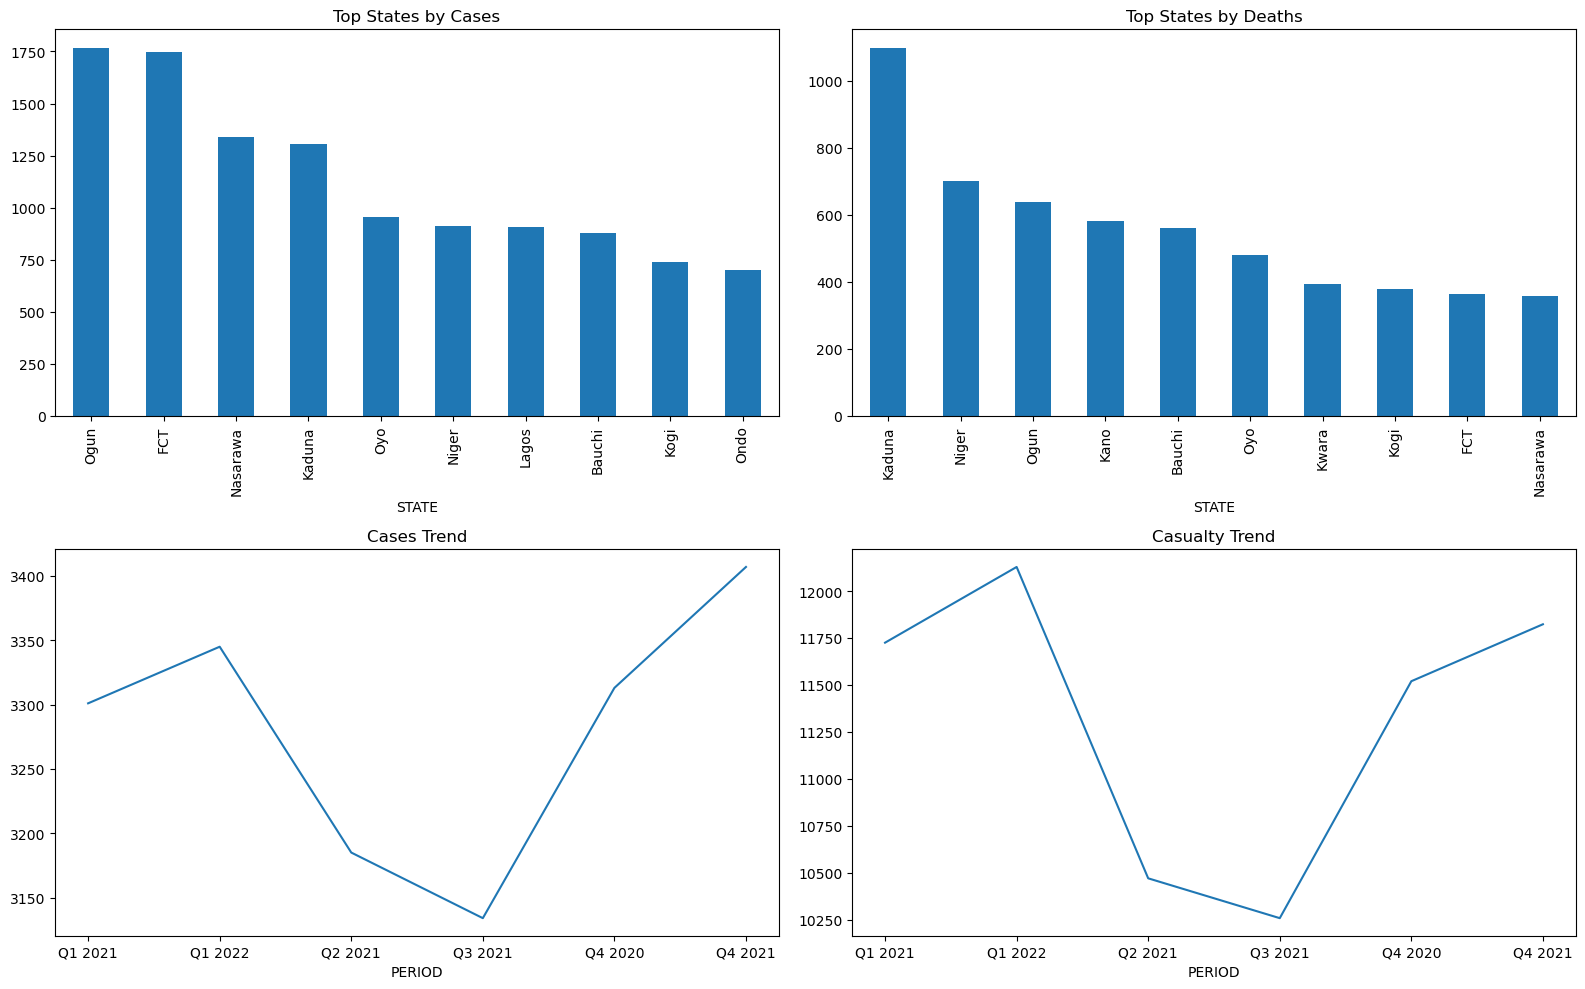

In [38]:
fig, axes = plt.subplots(2, 2,figsize=(16,10))

# Top Cases
top_cases.head(10).plot(kind='bar',ax=axes[0,0])

axes[0,0].set_title("Top States by Cases")

# Top Deaths
top_deaths.head(10).plot( kind='bar',ax=axes[0,1])

axes[0,1].set_title( "Top States by Deaths")

# Trend
cases_trend.plot( ax=axes[1,0])

axes[1,0].set_title( "Cases Trend")

# Casualty Trend
period_trend.plot( ax=axes[1,1])

axes[1,1].set_title("Casualty Trend")

plt.tight_layout()
plt.show()


# EXPORT STATE SUMMARY

In [39]:
state_summary.to_csv("state_accident_summary.csv")

print("\nAnalysis Completed Successfully!")
print("Summary exported as state_accident_summary.csv")


Analysis Completed Successfully!
Summary exported as state_accident_summary.csv
